### Import Libraries

In [46]:
import matplotlib.pyplot as plt

import torchaudio
import torchaudio.transforms as T

In [47]:
# Define variables
ROOT_PATH = r"ICBHI_final_database"

SAMPLING_RATE = 16000
AUDIO_LENGTH = 4.5
WINDOW_SIZE = int(AUDIO_LENGTH * SAMPLING_RATE)

Raw audio are just diturbance in any medium (like air), these disturbance can be record using specific types of ditectors, they record pressure made by any disturbance in air at any sampling rate (usually between 16 - 44KHz). They record amplitutes which can plot with respect to time. 

Below is the example of a waveform which recorded at a perticular sampling rate. I used only 1 second wavelength to display it more clearly.

In [48]:
sample_audio_path = r'ICBHI_final_database\221_2b1_Lr_mc_LittC2SE.wav'

In [49]:
# First we need to convert any other sampling rate waveform to an specific sampling rate in our case we are using 16K sampling rate per second.
# We can either tranform our audio with torchaudio or with librosa. It is much easier with librosa then torchaudio.

waveform, sr = torchaudio.load(sample_audio_path) # Load waveform
print("Original Length: ", waveform.shape)

resampler = T.Resample(
    orig_freq=sr,
    new_freq=SAMPLING_RATE
)

waveform = resampler(waveform)
sr = SAMPLING_RATE
print("waveform after resampling: ", waveform.shape)

Original Length:  torch.Size([1, 882000])
waveform after resampling:  torch.Size([1, 320000])


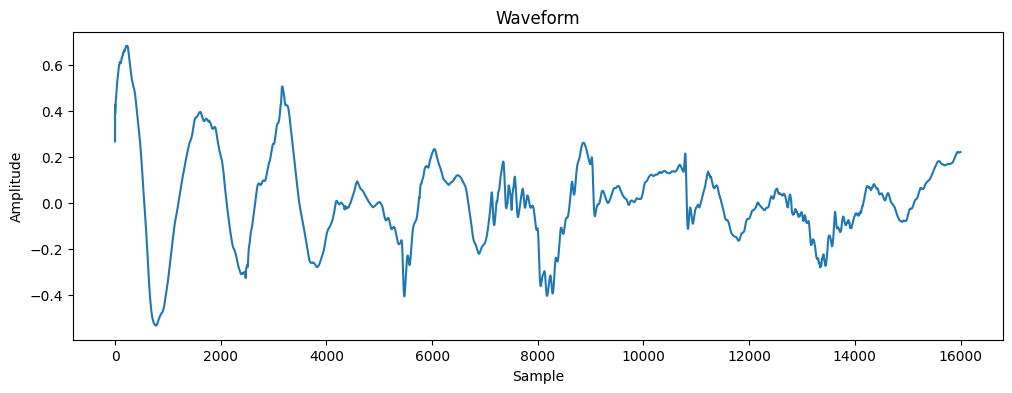

In [50]:
waveform = waveform[:, :sr] # Extract 1 second of waveform

# display waveform
plt.figure(figsize=(12, 4))
plt.plot(waveform[0].numpy())  # first channel
plt.title("Waveform")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

Now, although raw waveform are the exellent representation of a sound, but we cannot use them direct to feed our model.

It has two main disadvantage:
- Our audio may contain noise which can be misleading while training.
- And second most important, becuase of it's length, only 10 seconds of audio file contains 16000*10 number of information (sampling rate * time).

They may lead to problems like curse or dimensionality because of too much length.

That's why we must extract some important information from our raw waveform. Here are some techniques to get more important feature from a given waveform.

#### Spectrogram

The most famous and easy technique is to apply fourier transformation in time and amplitude domain of a given waveform. As a result we get spetrogram where in time-frequency domain, where time on x-axis, frequency or pitch on y-axis and color or brightness represent how loud and intense the given range is. 

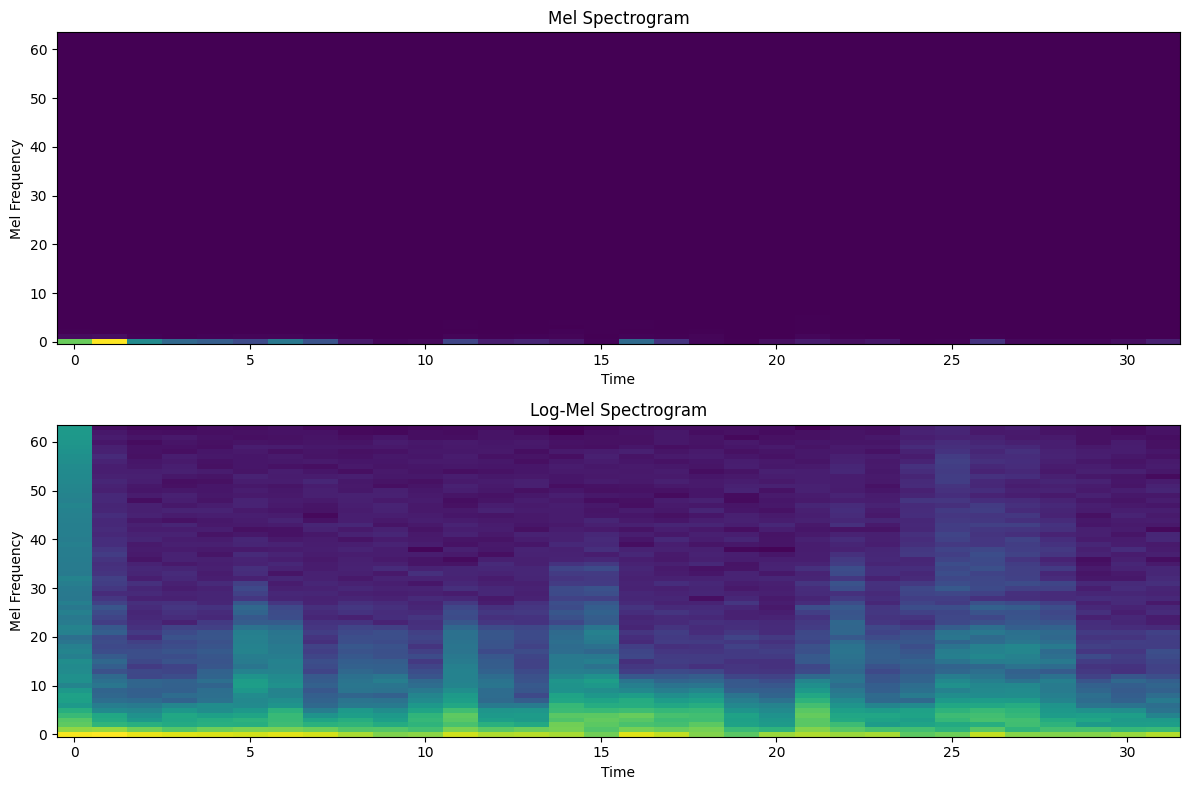

In [51]:
mel_transform = T.MelSpectrogram( 
    sample_rate=16000,
    n_fft=1024,
    hop_length=512,
    n_mels=64
) # Define a torchaudio mel spectrogram transformer class object
amplitude_to_db = T.AmplitudeToDB()

mel_spec = mel_transform(waveform)
log_mel_spec = amplitude_to_db(mel_spec)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Mel Spectrogram
axes[0].imshow(
    mel_spec[0].numpy(),
    aspect='auto',
    origin='lower'
)

axes[0].set_title("Mel Spectrogram")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Mel Frequency")

# Log-Mel Spectrogram
axes[1].imshow(
    log_mel_spec[0].numpy(),
    aspect='auto',
    origin='lower'
)

axes[1].set_title("Log-Mel Spectrogram")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Mel Frequency")

plt.tight_layout()
plt.show()

Here log-mel spectrogram is important to notice, we converted mel-spectrogram to log-mel spectrogram, because human's hearing perceives loudness as logarithmically not linearly. For example if we hear two 10DB sounds then it still 10DB (approx) but never 20DB. It is easy to notice the difference with 100 and 1000DB as compare to 1000DB and 1100DB.

Now even spectrogram and log-mel spectrogram are enough to process any audio and feed it to model. But we use some other techniques like MFCC, delta, delta-delta, etc.

#### Mel-Frequency Cepstral Coefficients (MFCCs)

Log-mel strogram are enough representation of an audio but MFCC compress that information in much small space, so instead of giving a model the entire spectrogram or log-mel spectrogram image, MFCC tries to summarize the important sound characteristics into a small set of numbers.

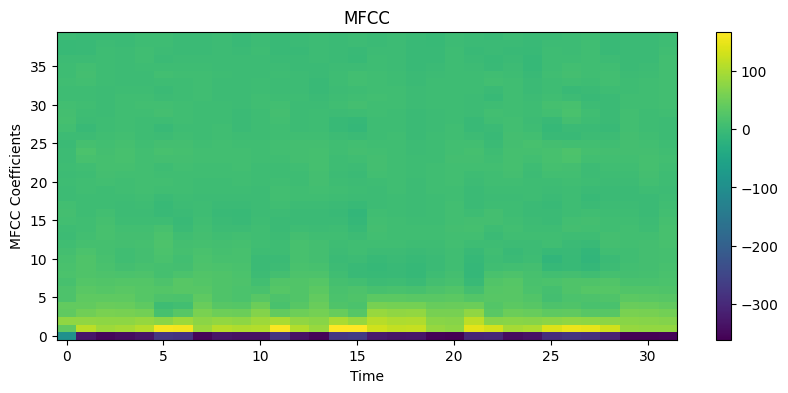

In [52]:
# Here is how we can convert any waveform to MFCC
mfcc_transform = T.MFCC(
    sample_rate=16000,
    n_mfcc=40,
    melkwargs={
        "n_fft": 1024,
        "hop_length": 512,
        "n_mels": 128,
    }
)

mfcc = mfcc_transform(waveform)

plt.figure(figsize=(10, 4))
plt.imshow(
    mfcc[0].numpy(),
    aspect='auto',
    origin='lower'
)

plt.title("MFCC")
plt.xlabel("Time")
plt.ylabel("MFCC Coefficients")
plt.colorbar()

plt.show()

In controry, we can test our model with all the feature extraction tenchnique, and find our which technique is more appropriate for. 

Last point to discuss: Although MFCC can have dense representation of an audio, we can use delta and delta-delta, which not only notice the frequencies of each timestamp but also the change in those MFCCs. Delta is basically time-derivate or rate of change of MFCCs.

`Change in mfcc =  current mfcc - previous mfcc`